<a href="https://colab.research.google.com/github/ENRIKO-18/D-DScience/blob/main/Protein_Proyect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **--|PROYECTO CIENCIA DE DATOS|--**

# 0. Lectura datos

In [80]:
import pandas as pd
from google.colab import files

In [81]:
upl = files.upload()
#file_name = "2018-06-06-pdb-intersect-pisces.csv"
file_name="base de datos-docking.csv"
pdf = pd.read_csv(file_name)

Saving base de datos-docking.csv to base de datos-docking.csv


# **1. Análisis del dataframe**

In [82]:
pdf.head(26)

,Subfamilia,PDB ID,Binding Affinty (kcal/mol),Inhibition Constant Micromol (x10-6),Binding energy (kcal/mol),Intermolecular Energy (kcal/mol),Internal Energy (kcal/mol),Torsional Energy (kcal/mol)
0,2E1,3E4E,-6.6,3100.000,-3.42,-6.40,-0.27,2.98
1,11A1,3N9Z,-7.7,48.530,-5.89,-8.87,-1.23,2.98
2,11B1,6M7X,-8.3,18.150,-6.47,-9.45,-1.23,2.98
3,11B2,4DVQ,-8.3,6.530,-7.07,-10.06,-1.02,2.98
4,17A1,3RUK,-7.3,150.820,-5.21,-8.20,-1.79,2.98
5,19A1,3S79,-7.6,11.450,-6.74,-9.72,-0.25,2.98
6,1A1,6DWM,-9.4,32.970,-6.11,-9.10,-1.04,2.98
7,1A2,2HI4,-9.5,29.660,-6.18,-9.16,-0.88,2.98
8,1B1,6OYU,-7.3,202.380,-5.04,-8.02,-1.63,2.98
9,21A2,4Y8W,-7.8,219.710,-4.99,-7.97,-1.88,2.98


1. Búsqueda de datos nulos




In [83]:
print(pdf.isna().sum())

Subfamilia                              0
PDB ID                                  0
Binding Affinty (kcal/mol)              0
Inhibition Constant Micromol (x10-6)    0
Binding energy (kcal/mol)               0
Intermolecular Energy (kcal/mol)        0
Internal Energy (kcal/mol)              0
Torsional Energy (kcal/mol)             0
dtype: int64


2. Tipo de datos del Dataframe

In [84]:
pdf.dtypes

,0
Subfamilia,object
PDB ID,object
Binding Affinty (kcal/mol),float64
Inhibition Constant Micromol (x10-6),float64
Binding energy (kcal/mol),float64
Intermolecular Energy (kcal/mol),float64
Internal Energy (kcal/mol),float64
Torsional Energy (kcal/mol),float64


## 3. Resumen general de dataframe

In [85]:
print(pdf.info)

<bound method DataFrame.info of    Subfamilia PDB ID  Binding Affinty (kcal/mol)  \
0         2E1   3E4E                        -6.6   
1        11A1   3N9Z                        -7.7   
2        11B1   6M7X                        -8.3   
3        11B2   4DVQ                        -8.3   
4        17A1   3RUK                        -7.3   
5        19A1   3S79                        -7.6   
6         1A1   6DWM                        -9.4   
7         1A2   2HI4                        -9.5   
8         1B1   6OYU                        -7.3   
9        21A2   4Y8W                        -7.8   
10        2A6   2FDW                        -5.3   
11        2B6   4I91                        -7.4   
12       2C19   4GQS                        -7.4   
13        2C8   2NV0                        -7.4   
14        2C9   1OG2                        -6.4   
15        2D6   4WNT                        -8.7   
16        2R1   3C6G                        -7.5   
17        3A4   1TQN            

## 4. Estadística general de las columnas

In [86]:
display(pdf.describe())

,Binding Affinty (kcal/mol),Inhibition Constant Micromol (x10-6),Binding energy (kcal/mol),Intermolecular Energy (kcal/mol),Internal Energy (kcal/mol),Torsional Energy (kcal/mol)
count,26.000000,26.000000,26.000000,26.000000,26.000000,2.600000e+01
mean,-7.434615,261.850115,-5.638462,-8.621923,-1.165000,2.980000e+00
std,0.934213,616.920378,0.942111,0.943381,0.440865,4.528839e-16
min,-9.500000,4.740000,-7.260000,-10.250000,-1.880000,2.980000e+00
25%,-7.675000,30.465750,-6.155000,-9.137500,-1.455000,2.980000e+00
50%,-7.400000,57.535000,-5.715000,-8.700000,-1.230000,2.980000e+00
75%,-7.200000,196.140000,-5.060000,-8.040000,-0.922500,2.980000e+00
max,-5.300000,3100.000000,-3.420000,-6.400000,-0.250000,2.980000e+00


5. Tipo de datos del dataframe

In [87]:
pdf.dtypes

,0
Subfamilia,object
PDB ID,object
Binding Affinty (kcal/mol),float64
Inhibition Constant Micromol (x10-6),float64
Binding energy (kcal/mol),float64
Intermolecular Energy (kcal/mol),float64
Internal Energy (kcal/mol),float64
Torsional Energy (kcal/mol),float64


# **2. Preprocesamiento**
2.1 Eliminación de duplicados

2.2 Eliminar columnas que no aportan información para CLUSTERING

2.3 Inspección de correlación para evitar MUlticolinearidad

2.4 Outliers

2.5 Escalamiento de variables

1. Elimino duplicados

In [88]:
pdf=pdf.drop_duplicates()
print(pdf.shape)

(25, 8)


In [89]:
 #Una copia del dataframe
pdf2=pdf.copy()

2.  Elimino columnas "Subfamilia", "PDB ID" y Torsional Energy" dado que el valor es constante.

In [90]:
pdf2=pdf2.drop(columns=["Subfamilia","PDB ID","Torsional Energy (kcal/mol)"])
pdf2.head()

,Binding Affinty (kcal/mol),Inhibition Constant Micromol (x10-6),Binding energy (kcal/mol),Intermolecular Energy (kcal/mol),Internal Energy (kcal/mol)
0,-6.6,3100.00,-3.42,-6.40,-0.27
1,-7.7,48.53,-5.89,-8.87,-1.23
2,-8.3,18.15,-6.47,-9.45,-1.23
3,-8.3,6.53,-7.07,-10.06,-1.02
4,-7.3,150.82,-5.21,-8.20,-1.79


## 3. Inspección de las relaciones entre varaibles para evitar multicolinearidad

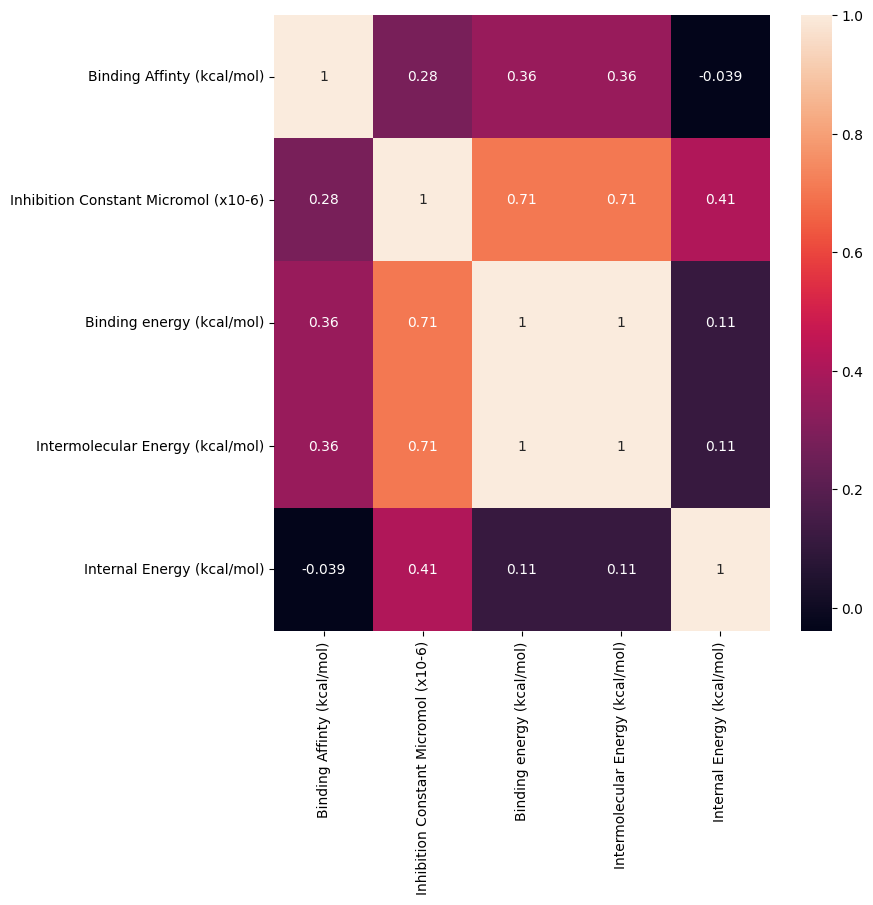

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

corrs=pdf2.corr()
plt.figure(figsize=(8,8))
sns.heatmap(corrs, annot=True)
plt.show()

<Figure size 1000x1000 with 0 Axes>

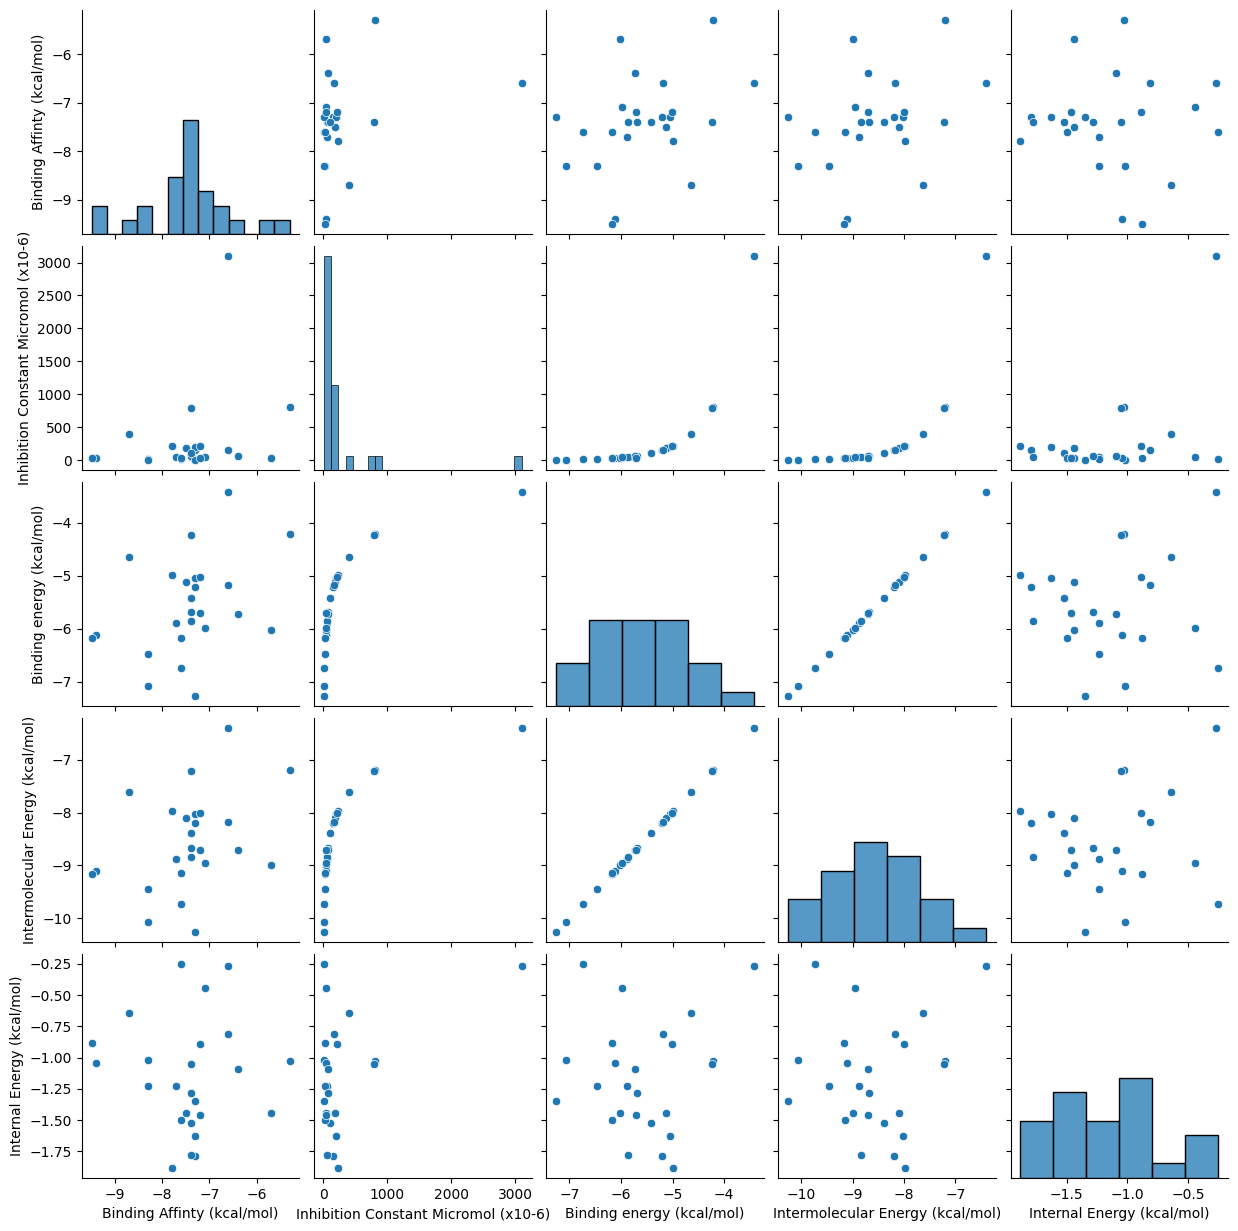

In [92]:
from seaborn import pairplot

plt.figure(figsize=(10,10))
pairplot(pdf2)
plt.show()

Se observa una muy alta correación entre las variables "Binding energy" e "Intermolecular Energy" por lo que opto por elminar "Intermolecular Energy"

In [93]:
pdf2=pdf2.drop(columns=["Intermolecular Energy (kcal/mol)"])
pdf2.head(25)

,Binding Affinty (kcal/mol),Inhibition Constant Micromol (x10-6),Binding energy (kcal/mol),Internal Energy (kcal/mol)
0,-6.6,3100.000,-3.42,-0.27
1,-7.7,48.530,-5.89,-1.23
2,-8.3,18.150,-6.47,-1.23
3,-8.3,6.530,-7.07,-1.02
4,-7.3,150.820,-5.21,-1.79
5,-7.6,11.450,-6.74,-0.25
6,-9.4,32.970,-6.11,-1.04
7,-9.5,29.660,-6.18,-0.88
8,-7.3,202.380,-5.04,-1.63
9,-7.8,219.710,-4.99,-1.88


## 4. Búsqueda de OUTLIERS

In [94]:
import pandas as pd
import numpy as np
from scipy import stats

Q1 = pdf2.quantile(0.25)
Q3 = pdf2.quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para identificar outliers. Un punto es un outlier si es menor que Q1 - 1.5 * IQR o mayor que Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Diccionario para almacenar los outliers por columna
outliers_by_column = {}

print("--- Análisis de Outliers por Columna (Método IQR) ---\n")

# Iterar sobre cada columna para encontrar los outliers
for column in pdf2.columns:
    # Identificar los outliers en la columna actual
    column_outliers = pdf2[(pdf2[column] < lower_bound[column]) | (pdf2[column] > upper_bound[column])]

    if not column_outliers.empty:
        outliers_by_column[column] = column_outliers[[column]] # Solo la columna que es outlier
        print(f"Outliers encontrados en la columna '{column}':")
        print(column_outliers[[column]]) # Mostro solo la columna con outliers
        print("-" * 50)
    else:
        outliers_by_column[column] = pd.DataFrame(columns=[column]) # DataFrame vacío si no hay outliers
        print(f"No se encontraron outliers en la columna '{column}'.")
        print("-" * 50)


--- Análisis de Outliers por Columna (Método IQR) ---

Outliers encontrados en la columna 'Binding Affinty (kcal/mol)':
    Binding Affinty (kcal/mol)
6                         -9.4
7                         -9.5
10                        -5.3
14                        -6.4
15                        -8.7
19                        -5.7
--------------------------------------------------
Outliers encontrados en la columna 'Inhibition Constant Micromol (x10-6)':
    Inhibition Constant Micromol (x10-6)
0                                3100.00
10                                813.04
12                                789.44
--------------------------------------------------
Outliers encontrados en la columna 'Binding energy (kcal/mol)':
   Binding energy (kcal/mol)
0                      -3.42
--------------------------------------------------
No se encontraron outliers en la columna 'Internal Energy (kcal/mol)'.
--------------------------------------------------


Boxplot de OUTLINERS

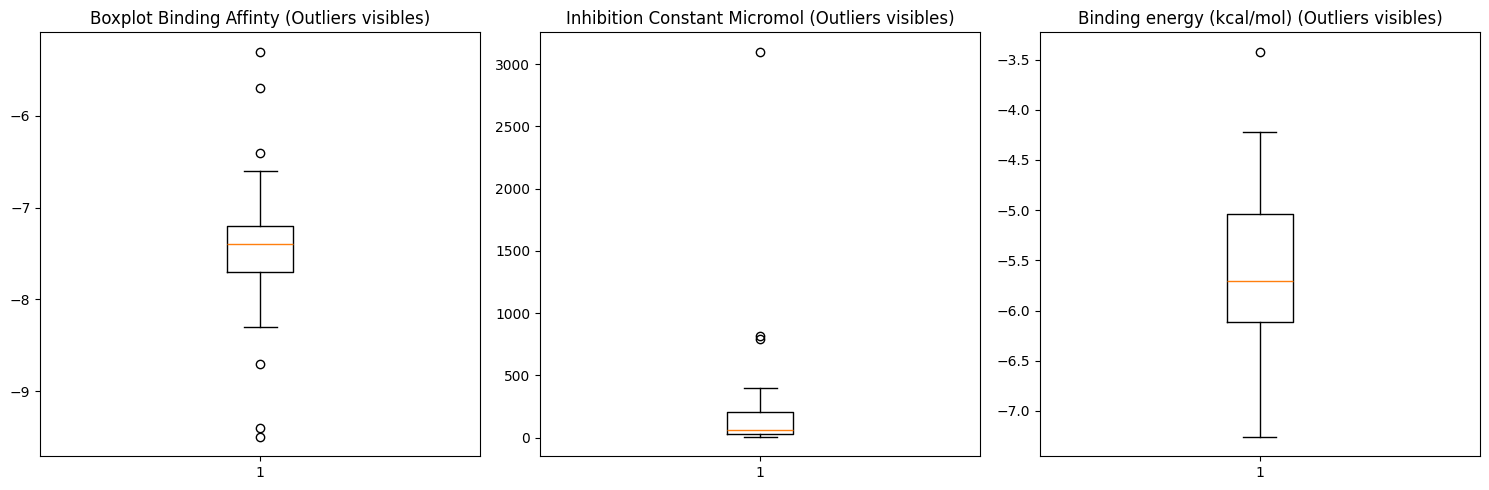

In [95]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Primer gráfico
axes[0].boxplot(pdf2['Binding Affinty (kcal/mol)'])
axes[0].set_title("Boxplot Binding Affinty (Outliers visibles)")

# Segundo gráfico
axes[1].boxplot(pdf2['Inhibition Constant Micromol (x10-6)'])
axes[1].set_title("Inhibition Constant Micromol (Outliers visibles)")

# Tercer gráfico
axes[2].boxplot(pdf2['Binding energy (kcal/mol)'])
axes[2].set_title("Binding energy (kcal/mol) (Outliers visibles)")

plt.tight_layout()
plt.show()

Tomo la desción de eliminar el Citocromo con índice 0 (3E4E) dado a que en dos de los parámetros resulta ser un OUTLIER

In [96]:
pdf2=pdf2.drop(index=0)
pdf2.head(25)

,Binding Affinty (kcal/mol),Inhibition Constant Micromol (x10-6),Binding energy (kcal/mol),Internal Energy (kcal/mol)
1,-7.7,48.530,-5.89,-1.23
2,-8.3,18.150,-6.47,-1.23
3,-8.3,6.530,-7.07,-1.02
4,-7.3,150.820,-5.21,-1.79
5,-7.6,11.450,-6.74,-0.25
6,-9.4,32.970,-6.11,-1.04
7,-9.5,29.660,-6.18,-0.88
8,-7.3,202.380,-5.04,-1.63
9,-7.8,219.710,-4.99,-1.88
10,-5.3,813.040,-4.22,-1.03


## 5. Escalamiento de datos

In [97]:
from sklearn.preprocessing import StandardScaler

#Inicialiso el escalador STANDAR SCALER
scal=StandardScaler()
#Fit y trasnform del escalar
pdf2_scal=scal.fit_transform(pdf2)
print(pdf2_scal)

[[-0.24016372 -0.49052926 -0.29038028 -0.08672246]
 [-0.88060032 -0.63141346 -1.03341217 -0.08672246]
 [-0.88060032 -0.68530004 -1.80206585  0.42749071]
 [ 0.18679401 -0.01616965  0.58076056 -1.45795758]
 [-0.13342429 -0.66248404 -1.37930633  2.312939  ]
 [-2.05473407 -0.5626872  -0.57221996  0.37851803]
 [-2.16147351 -0.57803699 -0.66189623  0.77029949]
 [ 0.18679401  0.22293468  0.79854577 -1.06617612]
 [-0.34690316  0.30330082  0.86260024 -1.67833465]
 [ 2.32158266  3.05480916  1.84903913  0.40300437]
 [ 0.08005457 -0.48125446 -0.2519476  -1.43347124]
 [ 0.08005457  2.94536653  1.83622824  0.35403169]
 [ 0.08005457 -0.39945073 -0.02135149 -0.20915417]
 [ 1.1474489  -0.41628449 -0.07259507  0.25608632]
 [-1.30755805  1.12750586  1.31098156  1.35797169]
 [-0.02668486  0.10718518  0.69605861 -0.60093563]
 [ 0.18679401 -0.69360099 -2.04547285 -0.38055856]
 [ 1.89462493 -0.53653226 -0.45692191 -0.60093563]
 [ 0.93397003  0.01902822  0.61919324  0.94170388]
 [ 0.08005457 -0.21047669  0.32

In [98]:
# Eliminar la primera fila del original
pdf_alineado=pdf.copy()
pdf_alineado = pdf.drop(['Torsional Energy (kcal/mol)', 'Intermolecular Energy (kcal/mol)'], axis=1,  inplace=True)
pdf_alineado = pdf.iloc[1:].reset_index(drop=True)

columnas_numericas = [
    'Binding Affinty (kcal/mol)','Inhibition Constant Micromol (x10-6)','Binding energy (kcal/mol)','Internal Energy (kcal/mol)']

# Convertir NumPy array a DataFrame
pdf2_scaled_df = pd.DataFrame(pdf2_scal, columns=columnas_numericas)
pdf2_scaled_df = pdf2_scaled_df.reset_index(drop=True)
pdf_scaled_df=pdf2_scaled_df.copy()

# Agregar columnas de contexto
pdf2_scaled_df['Subfamilia'] = pdf_alineado['Subfamilia'].values
pdf2_scaled_df['PDB ID'] = pdf_alineado['PDB ID'].values

# Reordenar para poner 'Subfamilia' y 'PDB ID' al inicio
cols = pdf2_scaled_df.columns.tolist()
cols_reorder = ['Subfamilia', 'PDB ID'] + [col for col in cols if col not in ['Subfamilia', 'PDB ID']]
pdf2_scaled_df = pdf2_scaled_df[cols_reorder]

# Verifica
pdf2_scaled_df.head()

,Subfamilia,PDB ID,Binding Affinty (kcal/mol),Inhibition Constant Micromol (x10-6),Binding energy (kcal/mol),Internal Energy (kcal/mol)
0,11A1,3N9Z,-0.240164,-0.490529,-0.290380,-0.086722
1,11B1,6M7X,-0.880600,-0.631413,-1.033412,-0.086722
2,11B2,4DVQ,-0.880600,-0.685300,-1.802066,0.427491
3,17A1,3RUK,0.186794,-0.016170,0.580761,-1.457958
4,19A1,3S79,-0.133424,-0.662484,-1.379306,2.312939


In [99]:
print(pdf2_scaled_df.shape)

(24, 6)


# **3. CLUSTERING**

## K-MEANS

Importación de librerías

In [100]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Implementación de K-means y evaluación con Silhouette score.

In [101]:
# Definir el número de clusters a buscar:
numK = 3

modelo = KMeans(n_clusters=numK,random_state=2)
k_clust=modelo.fit_predict(pdf2_scal)

#Evaluación con Silhouette
Sil_sc=silhouette_score(pdf2_scal,k_clust)
print(f"Score de Silhouette:{Sil_sc}")

Score de Silhouette:0.3472238055245458


Búsqueda del valor de codo

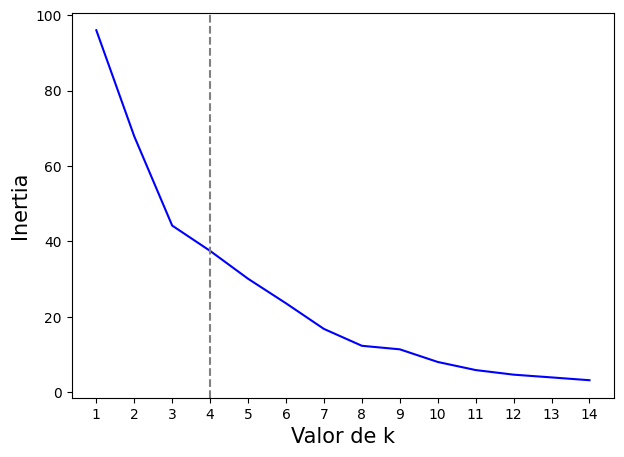

In [102]:
modelo.inertia_

max_num_clusters = 15

inertias = []
k_values = list(range(1,max_num_clusters))
for k in k_values:
    modelo = KMeans(n_clusters=k, n_init='auto')
    modelo.fit(pdf2_scal)
    inertias.append(modelo.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_values,inertias,color='blue')
plt.axvline(x=4,linestyle='dashed',color='gray')
plt.ylabel("Inertia", fontsize=15)
plt.xlabel("Valor de k", fontsize=15)
plt.xticks(k_values)
plt.show()

[link text](https://)Gŕafica del valor de silhouette

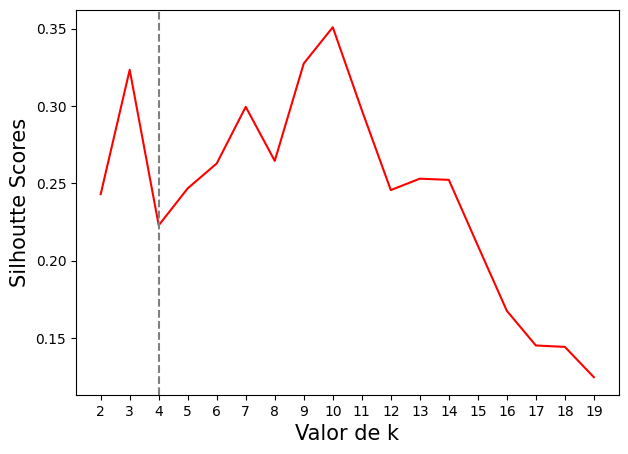

In [103]:
max_num_clusters = 20

best_num_clusters = 4

siluetas = []
k_values = list(range(2,max_num_clusters))
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init='auto').fit(pdf2_scal)
    labels = kmeans.labels_
    siluetas.append(silhouette_score(pdf2_scal, labels, metric='euclidean'))

plt.figure(figsize=(7,5))
plt.plot(k_values,siluetas,color='red')
plt.axvline(x=best_num_clusters,linestyle='dashed',color='gray')
plt.xticks(k_values)
plt.ylabel("Silhoutte Scores", fontsize=15)
plt.xlabel("Valor de k", fontsize=15)
plt.show()

Calinski-Harabasz Score (Variance Ratio Criterion)

In [104]:
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(pdf2_scal,k_clust)

print(f"Calinski-Harabasz Score: {ch_score:.2f}")

Calinski-Harabasz Score: 13.23


Hago lo mismo pero para distintos valores de K

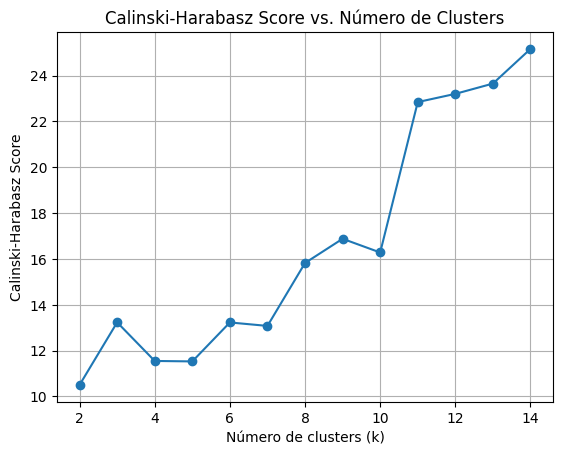

In [105]:
scores = []
ks = range(2, 15)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=2)
    labels = kmeans.fit_predict(pdf2_scal)
    score = calinski_harabasz_score(pdf2_scal,labels)
    scores.append(score)

# Visualizar
plt.plot(ks, scores, marker='o')
plt.title("Calinski-Harabasz Score vs. Número de Clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Calinski-Harabasz Score")
plt.grid(True)
plt.show()

### Las tres métricas en comparativa

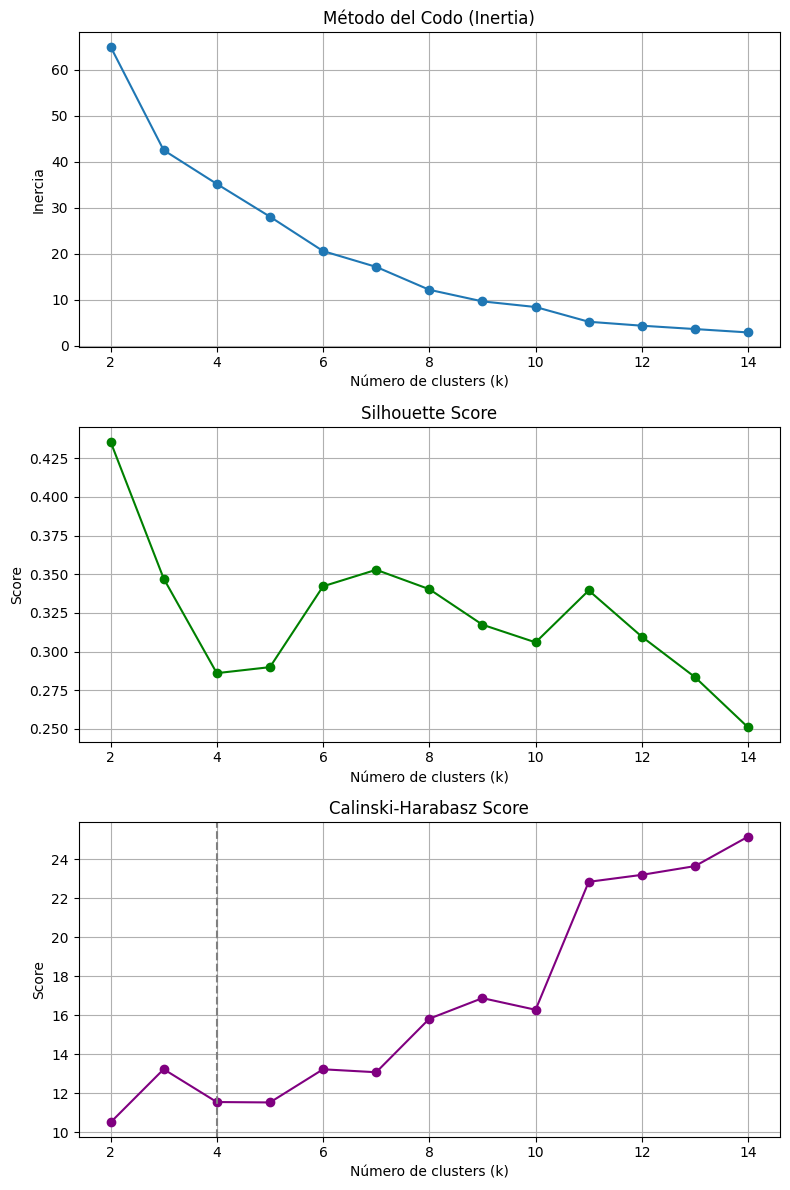

In [106]:
# Evaluando varios k
k_range = range(2, 15)
inertias = []
silhouette_scores = []
calinski_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=2)
    labels = kmeans.fit_predict(pdf2_scal)

    # Método del codo (inertia)
    inertias.append(kmeans.inertia_)

    # Silhouette Score
    silhouette_scores.append(silhouette_score(pdf2_scal, labels))

    # Calinski-Harabasz Score
    calinski_scores.append(calinski_harabasz_score(pdf2_scal, labels))

# 3. Visualizar resultados
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# Inercia (método del codo)
axs[0].plot(k_range, inertias, marker='o')
axs[0].set_title('Método del Codo (Inertia)')
axs[0].set_xlabel('Número de clusters (k)')
axs[0].set_ylabel('Inercia')

axs[0].grid(True)

# Silhouette Score
axs[1].plot(k_range, silhouette_scores, marker='o', color='green')
axs[1].set_title('Silhouette Score')
axs[1].set_xlabel('Número de clusters (k)')
axs[1].set_ylabel('Score')
axs[1].grid(True)

# Calinski-Harabasz Score
axs[2].plot(k_range, calinski_scores, marker='o', color='purple')
axs[2].set_title('Calinski-Harabasz Score')
axs[2].set_xlabel('Número de clusters (k)')
axs[2].set_ylabel('Score')
axs[2].grid(True)
plt.axvline(x=best_num_clusters,linestyle='dashed',color='gray')
plt.tight_layout()
plt.show()

## Agrupamiento de datos por K-Means

Considerando las gráficas, considero un k=3 como el óptimo a pesar de que el valor de codo se indica en k=4

In [107]:
numK = 3

k_modelo = KMeans(n_clusters=numK,random_state=2)
k_clust=k_modelo.fit_predict(pdf2_scal)

#Evaluación con Silhouette
Sil_sc=silhouette_score(pdf2_scal,k_clust)
print(f"Score de Silhouette:{Sil_sc}")

Score de Silhouette:0.3472238055245458


Con el valor de K, extraigo las etiquetas de los clusters y añado al dataframe

In [108]:
k_pdf=pdf2_scaled_df.copy() #copia del datafrmae escalado
k_pdf['cluster_label'] = k_clust
k_pdf.head(25)

,Subfamilia,PDB ID,Binding Affinty (kcal/mol),Inhibition Constant Micromol (x10-6),Binding energy (kcal/mol),Internal Energy (kcal/mol),cluster_label
0,11A1,3N9Z,-0.240164,-0.490529,-0.290380,-0.086722,0
1,11B1,6M7X,-0.880600,-0.631413,-1.033412,-0.086722,2
2,11B2,4DVQ,-0.880600,-0.685300,-1.802066,0.427491,2
3,17A1,3RUK,0.186794,-0.016170,0.580761,-1.457958,0
4,19A1,3S79,-0.133424,-0.662484,-1.379306,2.312939,2
5,1A1,6DWM,-2.054734,-0.562687,-0.572220,0.378518,2
6,1A2,2HI4,-2.161474,-0.578037,-0.661896,0.770299,2
7,1B1,6OYU,0.186794,0.222935,0.798546,-1.066176,0
8,21A2,4Y8W,-0.346903,0.303301,0.862600,-1.678335,0
9,2A6,2FDW,2.321583,3.054809,1.849039,0.403004,1


In [109]:
# Obtener la lista única de etiquetas de cluster
unique_clusters = sorted(k_pdf['cluster_label'].unique())

# Iterar sobre cada cluster y mostrar los títulos de las películas
for cluster_id in unique_clusters:
    print(f"\n---Proteinas en cluster {cluster_id}---")
    # Filtrar el DataFrame para obtener solo las películas de este cluster
    prot_cluster =k_pdf[k_pdf['cluster_label'] == cluster_id]
    # Mouestro solo la columna 'title'
    print(prot_cluster ['Subfamilia'].to_frame().reset_index(drop=True))


---Proteinas en cluster 0---
   Subfamilia
0        11A1
1        17A1
2         1B1
3        21A2
4         2B6
5         2C8
6         2C9
7         2R1
8         3A5
9         3A7
10       46A1
11       51A1
12        7A1
13        8B1

---Proteinas en cluster 1---
  Subfamilia
0        2A6
1       2C19
2        2D6

---Proteinas en cluster 2---
  Subfamilia
0       11B1
1       11B2
2       19A1
3        1A1
4        1A2
5        3A4
6        8A1


## DBSCAN

In [110]:
from sklearn.cluster import DBSCAN
import numpy as np

### Implementación de Modelo

In [111]:
dbscan=DBSCAN(0.8,min_samples=3)
yhat=dbscan.fit_predict(pdf2_scal)

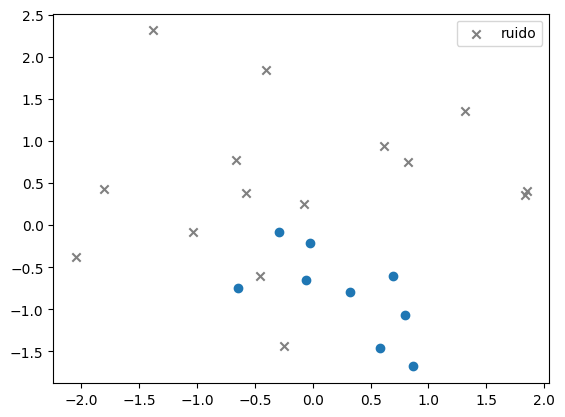

In [112]:
clusters = [j for j in np.unique(yhat) if j!=-1]

plt.figure()
plt.scatter(pdf2_scal[yhat==-1,2],pdf2_scal[yhat==-1,3],marker='x',color='gray',label='ruido')
for cluster in clusters:
    filas = np.where(yhat == cluster)
    plt.scatter(pdf2_scal[filas, 2], pdf2_scal[filas, 3])
plt.legend(loc='best')
plt.show()

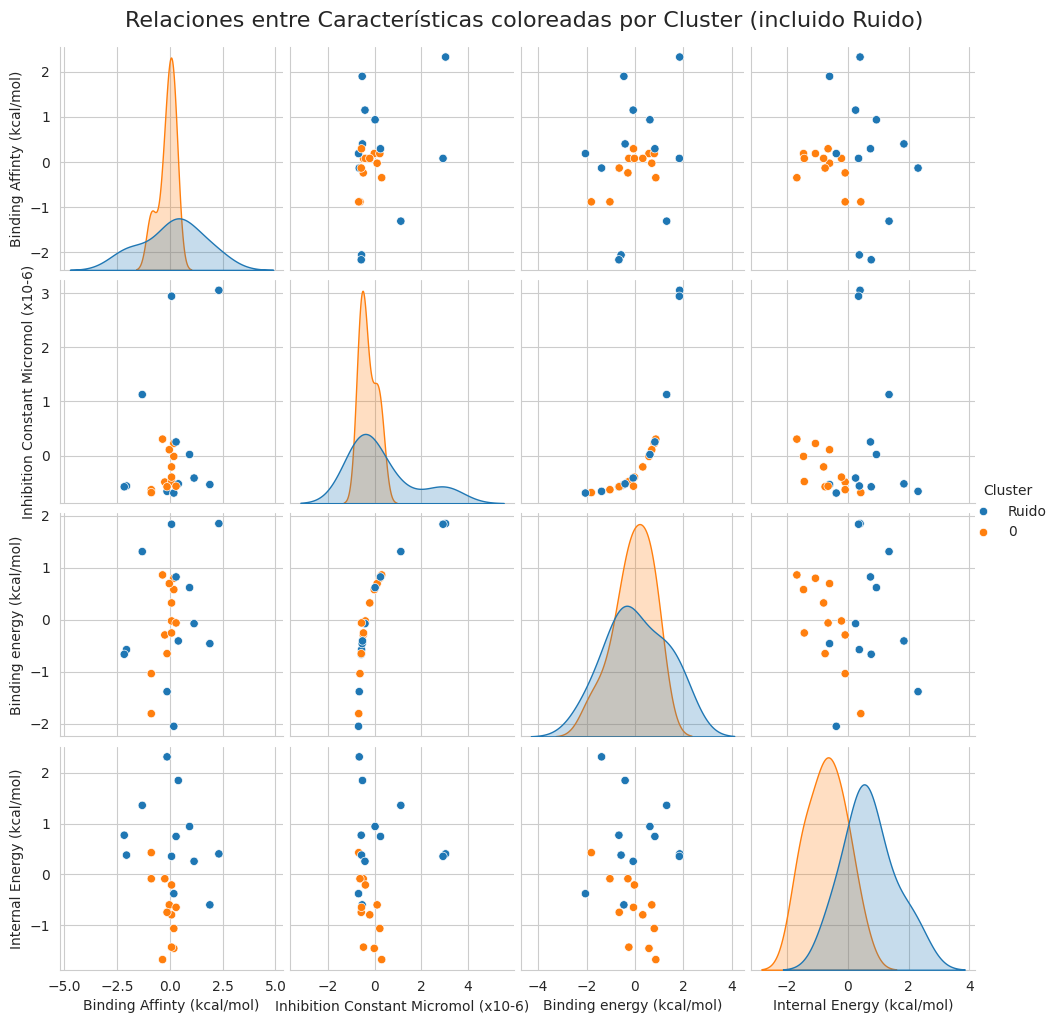

In [113]:
dbscan = DBSCAN(eps=1, min_samples=3)
yhat = dbscan.fit_predict(pdf_scaled_df)

# Añadir las etiquetas de cluster (incluyendo -1 para ruido) como una nueva columna
pdf_scaled_df['Cluster'] = yhat

# --- 3. Generar el Pairplot con 'hue' para los clusters/ruido ---
sns.set_style("whitegrid") # Opcional: estilo para los gráficos

pair_plot = sns.pairplot(pdf_scaled_df, hue='Cluster', palette='tab10', diag_kind='kde')

for text in pair_plot._legend.texts:
    if text.get_text() == '-1':
        text.set_text('Ruido')

pair_plot.fig.suptitle("Relaciones entre Características coloreadas por Cluster (incluido Ruido)", y=1.02, fontsize=16)

plt.show()

Evaluando diferentes valores de epsilon

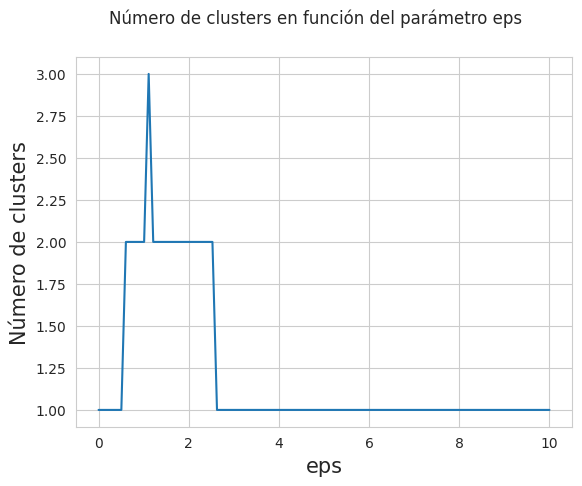

In [114]:
valores_eps = np.linspace(0.0001,10,100)
num_clusters = []

for eps in valores_eps:
    modelo = DBSCAN(eps=eps, min_samples=3)
    yhat = modelo.fit_predict(pdf2_scal)
    clusters = np.unique(yhat)
    num_clusters.append(len(clusters))

plt.plot(valores_eps,num_clusters)
plt.suptitle("Número de clusters en función del parámetro eps")
plt.xlabel("eps",fontsize=15)
plt.ylabel("Número de clusters", fontsize=15)
plt.show()

### Evaluación con Silhouette y Calinski-Harabasz

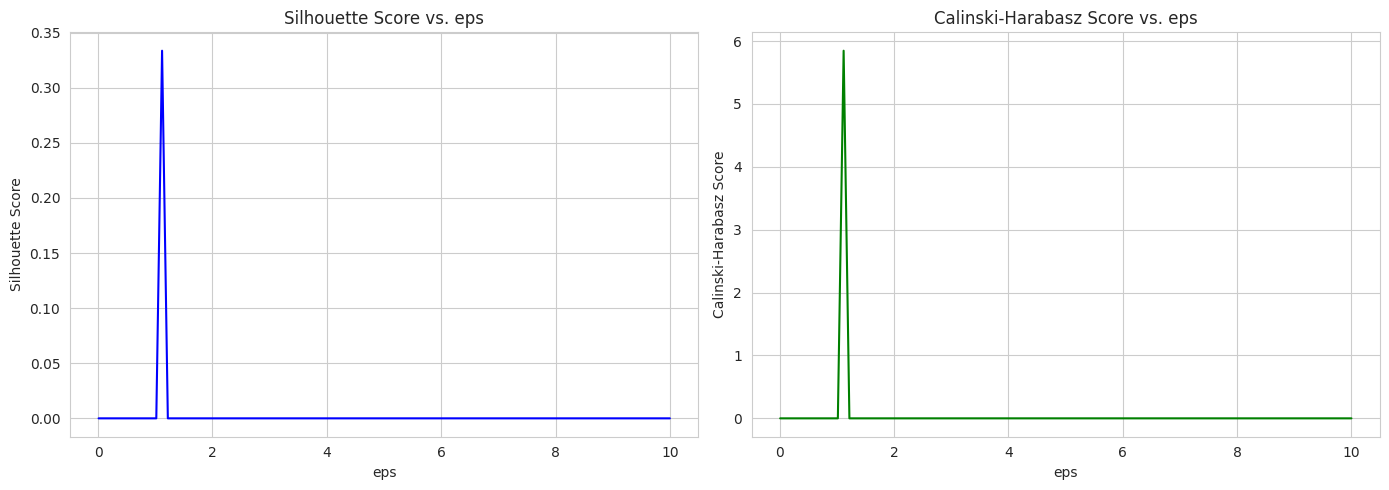

In [115]:
valores_eps = np.linspace(0.01, 10, 100)
siluetas = []
calinskis = []

for eps in valores_eps:
    modelo = DBSCAN(eps=eps, min_samples=3)
    yhat = modelo.fit_predict(pdf2_scal)

    # Filtrao puntos que no sean outliers (yhat != -1)
    mask = yhat != -1
    X_filtrado = pdf2_scal[mask]
    y_filtrado = yhat[mask]

    n_clusters = len(set(y_filtrado))

    # Verifico que haya al menos 2 clusters válidos
    if n_clusters >= 2:
        sil = silhouette_score(X_filtrado, y_filtrado)
        ch = calinski_harabasz_score(X_filtrado, y_filtrado)
    else:
        sil = 0
        ch = 0

    siluetas.append(sil)
    calinskis.append(ch)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette
axes[0].plot(valores_eps, siluetas, label='Silhouette Score', color='blue')
axes[0].set_title("Silhouette Score vs. eps")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True)

# Calinski-Harabasz
axes[1].plot(valores_eps, calinskis, label='Calinski-Harabasz Score', color='green')
axes[1].set_title("Calinski-Harabasz Score vs. eps")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("Calinski-Harabasz Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Clustering Jerárquico

In [116]:
from sklearn.cluster import AgglomerativeClustering

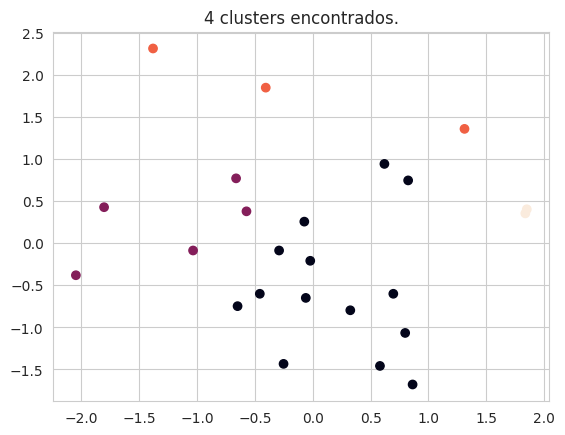

In [117]:
hiera = AgglomerativeClustering(distance_threshold=None,n_clusters=4,compute_full_tree=True)

yhat = hiera.fit_predict(pdf2_scal)
num_clusters_encontrados = np.unique(yhat).shape[0]

plt.figure()
plt.scatter(pdf2_scal[:, 2], pdf2_scal[:, 3], c=yhat)
plt.title(f"{num_clusters_encontrados} clusters encontrados.")
plt.show()

### # Aplicar Agglomerative Clustering

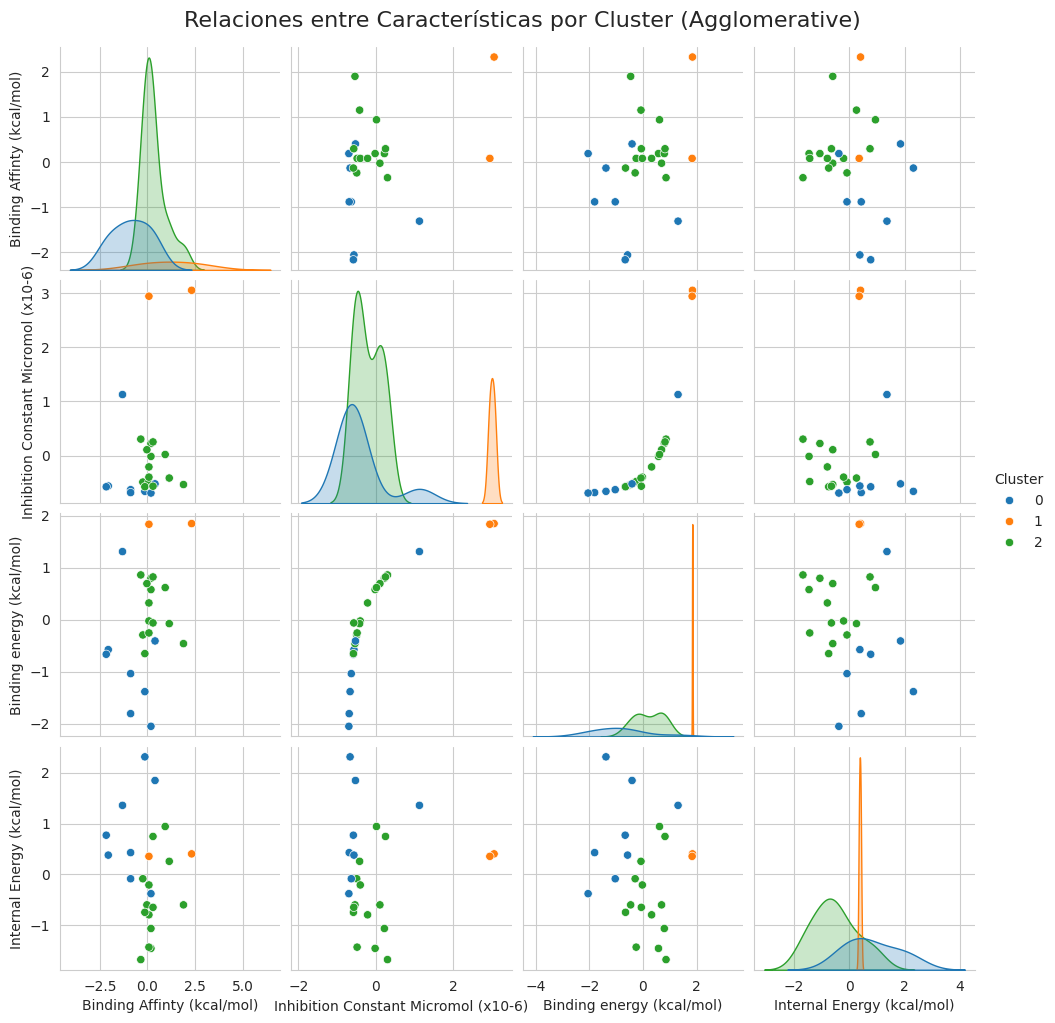

In [118]:
umbral=5
hiera= AgglomerativeClustering(n_clusters=None, metric='euclidean', linkage='ward', distance_threshold=umbral, compute_full_tree=True)
yhat = hiera.fit_predict(pdf2_scal)

yhat = hiera.fit_predict(pdf2_scal)

pdf2_scaled_df['Cluster'] = yhat

# Visualización con Pairplot
sns.set_style("whitegrid")
pair_plot = sns.pairplot(pdf2_scaled_df, hue='Cluster', palette='tab10', diag_kind='kde')
pair_plot.fig.suptitle("Relaciones entre Características por Cluster (Agglomerative)", y=1.02, fontsize=16)

plt.show()

### Generación del dendograma

In [119]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

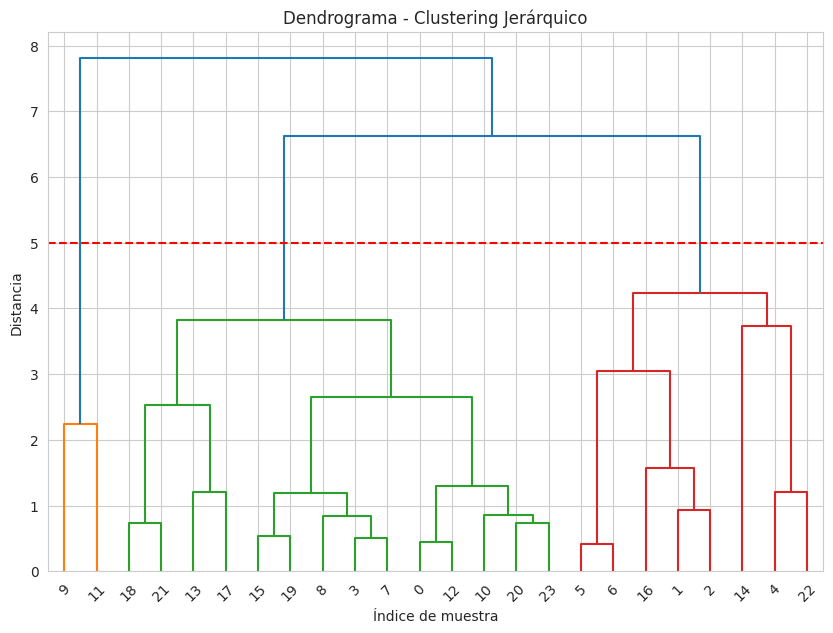

In [120]:
m_enlace = linkage(pdf2_scal, method='ward')
labels = fcluster(m_enlace, t=umbral, criterion='distance')

plt.figure(figsize=(10, 7))
dendrogram(m_enlace)
plt.axhline(y=umbral, color='r', linestyle='--')  # línea para tu umbral actual
plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Índice de muestra")
plt.ylabel("Distancia")
plt.show()

### Evaluación de CLuster Jerárquico

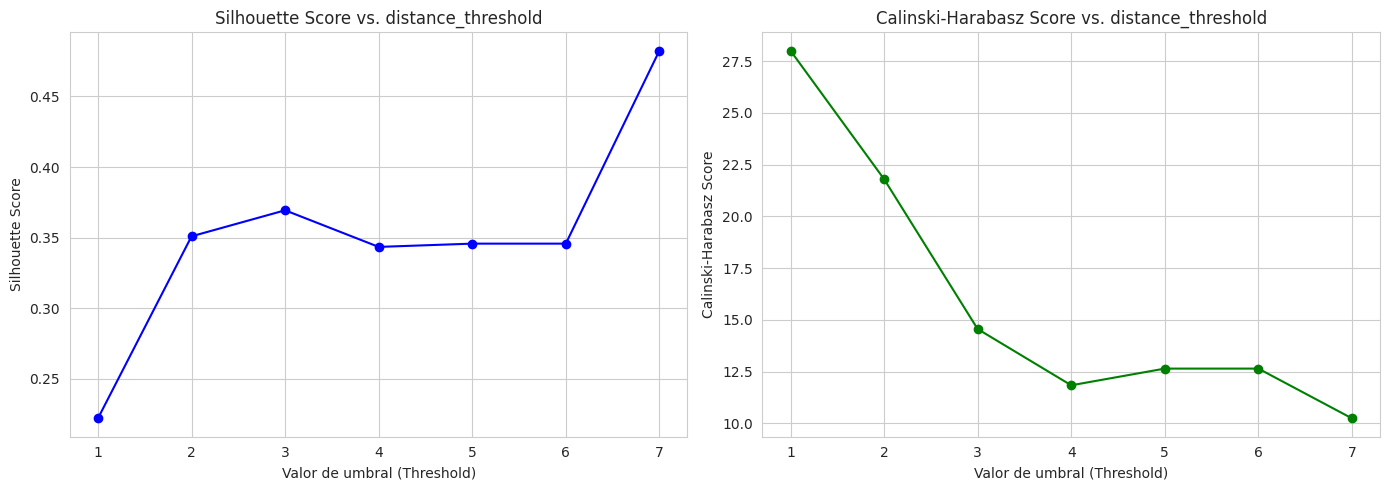

In [121]:
# Rango de número de clusters a evaluar
valores_k = range(1, 8)

siluetas = []
calinskis = []

for k in valores_k:
    modelo=AgglomerativeClustering(n_clusters=None, metric='euclidean', linkage='ward', distance_threshold=k, compute_full_tree=True) #Para evaluar en diversos umbrales
    #modelo = AgglomerativeClustering(n_clusters=k, linkage='ward')  # o 'complete', 'average', etc.   #Para evaluar con diversos n_clusters
    yhat = modelo.fit_predict(pdf2_scal)

    # Evaluar las métricas
    sil = silhouette_score(pdf2_scal, yhat)
    ch = calinski_harabasz_score(pdf2_scal, yhat)

    siluetas.append(sil)
    calinskis.append(ch)

# Graficar los resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette
axes[0].plot(valores_k, siluetas, marker='o', color='blue')
axes[0].set_title("Silhouette Score vs. distance_threshold")
axes[0].set_xlabel("Valor de umbral (Threshold)")
#axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True)

# Calinski-Harabasz
axes[1].plot(valores_k, calinskis, marker='o', color='green')
axes[1].set_title("Calinski-Harabasz Score vs. distance_threshold")
axes[1].set_xlabel("Valor de umbral (Threshold)")
#axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Calinski-Harabasz Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Resultado del culsterisado de proteinas

In [122]:
# Agrupar proteínas por cluster
agrupado = pdf2_scaled_df.groupby('Cluster')['Subfamilia'].apply(list)

# Mostrar resultados
for cluster_id, lista_proteinas in agrupado.items():
    print(f"🔹 Cluster {cluster_id} ({len(lista_proteinas)} proteínas):")
    print(", ".join(lista_proteinas))
    print("-" * 50)

🔹 Cluster 0 (8 proteínas):
11B1, 11B2, 19A1, 1A1, 1A2, 2D6, 3A4, 8A1
--------------------------------------------------
🔹 Cluster 1 (2 proteínas):
2A6, 2C19
--------------------------------------------------
🔹 Cluster 2 (14 proteínas):
11A1, 17A1, 1B1, 21A2, 2B6, 2C8, 2C9, 2R1, 3A5, 3A7, 46A1, 51A1, 7A1, 8B1
--------------------------------------------------


# **4. Análisis de resultados y discusión**

## Mutual information

Dataframe con salida del cluster K-Means

In [158]:
prot_cluster=k_pdf.copy()
prot_cluster.head(24)

,Subfamilia,PDB ID,Binding Affinty (kcal/mol),Inhibition Constant Micromol (x10-6),Binding energy (kcal/mol),Internal Energy (kcal/mol),cluster_label
0,11A1,3N9Z,-0.240164,-0.490529,-0.290380,-0.086722,0
1,11B1,6M7X,-0.880600,-0.631413,-1.033412,-0.086722,2
2,11B2,4DVQ,-0.880600,-0.685300,-1.802066,0.427491,2
3,17A1,3RUK,0.186794,-0.016170,0.580761,-1.457958,0
4,19A1,3S79,-0.133424,-0.662484,-1.379306,2.312939,2
5,1A1,6DWM,-2.054734,-0.562687,-0.572220,0.378518,2
6,1A2,2HI4,-2.161474,-0.578037,-0.661896,0.770299,2
7,1B1,6OYU,0.186794,0.222935,0.798546,-1.066176,0
8,21A2,4Y8W,-0.346903,0.303301,0.862600,-1.678335,0
9,2A6,2FDW,2.321583,3.054809,1.849039,0.403004,1


Dataframe con salida de Clustering Jerárquico

In [151]:
pdf2_scaled_df.head(24)

,Subfamilia,PDB ID,Binding Affinty (kcal/mol),Inhibition Constant Micromol (x10-6),Binding energy (kcal/mol),Internal Energy (kcal/mol),Cluster
0,11A1,3N9Z,-0.240164,-0.490529,-0.290380,-0.086722,2
1,11B1,6M7X,-0.880600,-0.631413,-1.033412,-0.086722,0
2,11B2,4DVQ,-0.880600,-0.685300,-1.802066,0.427491,0
3,17A1,3RUK,0.186794,-0.016170,0.580761,-1.457958,2
4,19A1,3S79,-0.133424,-0.662484,-1.379306,2.312939,0
5,1A1,6DWM,-2.054734,-0.562687,-0.572220,0.378518,0
6,1A2,2HI4,-2.161474,-0.578037,-0.661896,0.770299,0
7,1B1,6OYU,0.186794,0.222935,0.798546,-1.066176,2
8,21A2,4Y8W,-0.346903,0.303301,0.862600,-1.678335,2
9,2A6,2FDW,2.321583,3.054809,1.849039,0.403004,1


Merge en "prot_cluster" de salidas de ambos métodos de clustering y eliminación de métricas

In [159]:
prot_cluster = prot_cluster.merge(pdf2_scaled_df[['Subfamilia', 'PDB ID', 'Cluster']],on=['Subfamilia', 'PDB ID'],how='left')
#Renombro las columnas
prot_cluster.rename(columns={'cluster_label':'Cluster_K-means', 'Cluster':'Cluster_Jerárquico' }, inplace=True)
prot_cluster = prot_cluster[['Subfamilia', 'PDB ID', 'Cluster_K-means', 'Cluster_Jerárquico']]
prot_cluster.head(25)

,Subfamilia,PDB ID,Cluster_K-means,Cluster_Jerárquico
0,11A1,3N9Z,0,2
1,11B1,6M7X,2,0
2,11B2,4DVQ,2,0
3,17A1,3RUK,0,2
4,19A1,3S79,2,0
5,1A1,6DWM,2,0
6,1A2,2HI4,2,0
7,1B1,6OYU,0,2
8,21A2,4Y8W,0,2
9,2A6,2FDW,1,1


In [168]:
from sklearn.metrics import mutual_info_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import adjusted_mutual_info_score

MUTUAL INFORMATION (MI) entre [0, inf)

In [171]:
mi=mutual_info_score(prot_cluster['Cluster_K-means'],prot_cluster['Cluster_Jerárquico'])
print(f"Mutual Information Score: {mi_score:.2f}")

Mutual Information Score: 0.81


MUTUAL INFORMATION NORMALIZADO (NMI) entre[0,1]

In [166]:
nmi = normalized_mutual_info_score(prot_cluster['Cluster_K-means'],prot_cluster['Cluster_Jerárquico'])
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Normalized Mutual Information (NMI): 0.8874


MUTUAL INFORMATION AJUSTADO (AMI) entre [-1, 1]

In [169]:
ami = adjusted_mutual_info_score(prot_cluster['Cluster_K-means'],prot_cluster['Cluster_Jerárquico'])
print(f"Adjusted Mutual Information (AMI): {ami:.4f}")

Adjusted Mutual Information (AMI): 0.8736


COMPARACIÓN

In [172]:
resultados = pd.DataFrame({'Métrica': ['Mutual Information', 'Normalized MI', 'Adjusted MI'],'Valor': [mi, nmi, ami]})
print(resultados)

              Métrica     Valor
0  Mutual Information  0.808130
1       Normalized MI  0.887365
2         Adjusted MI  0.873605


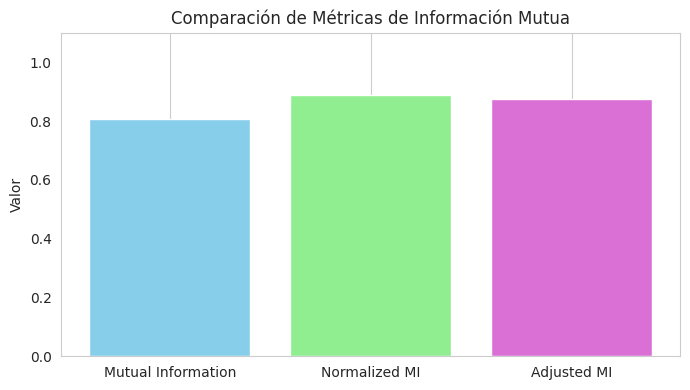

In [173]:
plt.figure(figsize=(7, 4))
plt.bar(resultados['Métrica'], resultados['Valor'], color=['skyblue', 'lightgreen', 'orchid'])
plt.ylim(0, 1.1)
plt.title("Comparación de Métricas de Información Mutua")
plt.ylabel("Valor")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Conclusiones

**DEL CLUSTERING**

Aplicando y analizando los tres tipso de infromacion mutua (MI, NMI, AMI) vemos que on valores muy altos (prox. a 1), lo que me permite afirmar que:

1. Los dos modelso de clustering (K-means y Jerárquico) están generando agrupaciones altamente consistentes entre sí.
2. Ambos identifican estructuras similares en los datos, lo que da confianza en la estabilidad de los clusters formados.
3. El AMI refuerza que la similitud no es debida al azar, lo que es un excelente respaldo.

**DEl PROYECTO**

* Dado que ambos modelos encuentran estructuras similares, con un grupo dominante, un grupo pequeño bien separado, y otro grupo intermedio es posible que se puedan identtificar 3 grupos funcionales en lugar de los 11 familias estructurales analizadas.
* Este trabajo preliminar resulta relevante para continuar analizando con mas estructuras, con la premisa de una posible formación de grupamientos funcionales, con base en los datos termodinámicos de dockeo, en este estudio, entre citocromos (P45) y el plastificante (MEHP).

* Como trabajo futuro, se necesita impelementar de manera mas "fina" el DBSCAN para valorar con un 3er. método la veracidad de estos resultados.
